# 01 — Load Interurban Road Network (Spain)

**In plain terms:**
- **What:** Build the map of Spain's *interurban* roads — the autopistas, autovías, and carreteras nacionales that connect cities.
- **Why:** The datathon rules (Section 2, *Scope of Analysis*) restrict proposed charging stations to interurban roads only. We need an authoritative road network first.
- **Source:** CNIG "Redes de Transporte" shapefile (= Ministry of Transport geometry, Section 4.1 item 1 of the datathon PDF).
- **Output:** `data/processed/roads_interurban.geojson` (the spatial backbone used by notebooks 02, 03, 04).

### Download steps

1. Go to [centrodedescargas.cnig.es/CentroDescargas/redes-transporte](https://centrodedescargas.cnig.es/CentroDescargas/redes-transporte)
2. Click the cart icon next to **"Toda España"** in **SHAPEFILE** format (~62 MB)
3. Click "Proceder a descarga" → enter your email → download the `.zip`
4. Inside the outer zip, find **`RT_VIARIA_CARRETERA.zip`** and extract it
5. Place the contents in `data/raw/cnig_roads/RT_VIARIA_CARRETERA/`

### Filtering strategy (two-step)

1. **State ownership:** `titulard == 'Administración General del Estado'` → removes Comunidad Autónoma / local roads.
2. **Core interurban designations:**
   - `AP-*` — Autopistas (toll), all numbers
   - `A-*` — Autovías, **1-2 digit only** (A-1 to A-92) → excludes connectors like A-4301
   - `N-*` — Carreteras Nacionales, all numbers

### Expected output

| Type | Roads | Segments | Notes |
|---|---|---|---|
| Autopistas (AP-\*) | ~15 | ~5k | e.g. AP-7, AP-2, AP-68 |
| Autovías (A-\*) | ~55 | ~128k | A-1 to A-92 (1-2 digit) |
| Nacionales (N-\*) | ~121 | ~84k | e.g. N-I, N-340 |
| **Total** | **~191** | **~217k** | **~48,000 km (CNIG dual-counts directions)** |


## Setup
- Load `geopandas`/`shapely` for the shapefile + spatial ops.
- Standard scientific stack (`pandas`, `numpy`, `matplotlib`) for tables and plots.
- No external API calls: everything runs offline once the CNIG shapefile is placed on disk.
- Silencing warnings to keep notebook output clean for the jury.


In [1]:
# Install dependencies (Colab)
# !pip install geopandas requests shapely pyproj -q

import geopandas as gpd
import pandas as pd
import numpy as np
import warnings
import os
import re
from shapely.geometry import LineString
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("Libraries loaded.")


Libraries loaded.


## 1. Load CNIG shapefile

- **File:** `rt_tramo_vial.shp` (~600 MB raw, ~1.8M segments covering every road in Spain).
- **Why a SQL WHERE:** loading 1.8M features into memory is wasteful; we only need AP-/A-/N-.
- **Fallback:** if the driver does not support SQL push-down, we load everything and post-filter.
- **Auto-discovery:** we scan common `data/raw/` paths so the notebook is portable across setups.


In [2]:
# ── Search for CNIG shapefile ──

CNIG_DIRS = [
    "../data/raw/cnig_roads/",
    "../data/raw/red_transporte_espana/",
    "../data/raw/",
]

roads_gdf = None
shp_path = None

# Find rt_tramo_vial.shp (or similar road shapefile)
for search_dir in CNIG_DIRS:
    if not os.path.exists(search_dir):
        continue
    for root, dirs, files in os.walk(search_dir):
        for f in files:
            if f.endswith('.shp') and ('tramo' in f.lower() or 'vial' in f.lower()):
                shp_path = os.path.join(root, f)
                break
        if shp_path:
            break
    if shp_path:
        break

if shp_path:
    print(f"Found CNIG shapefile: {shp_path}")
    fsize = os.path.getsize(shp_path) / 1024 / 1024
    print(f"  Size: {fsize:.0f} MB")

    # Load with SQL WHERE filter (much faster than loading all 1.8M features)
    print("\nLoading with SQL filter (AP-/A-/N- roads only)...")
    print("This may take 1-2 minutes for large files...")

    try:
        roads_gdf = gpd.read_file(
            shp_path,
            where="nombre LIKE 'AP-%' OR nombre LIKE 'A-%' OR nombre LIKE 'N-%'"
        )
        print(f"  Loaded with SQL filter: {len(roads_gdf):,} features")
    except Exception as e:
        print(f"  SQL filter not supported ({e}), loading full file...")
        roads_gdf = gpd.read_file(shp_path)
        # Post-filter
        mask = roads_gdf['nombre'].str.match(r'^(AP-|A-|N-)', na=False)
        roads_gdf = roads_gdf[mask].copy()
        print(f"  Loaded and post-filtered: {len(roads_gdf):,} features")

    print(f"  CRS: {roads_gdf.crs}")
    print(f"\n==> Initial load: {len(roads_gdf):,} segments with AP-/A-/N- names")
else:
    print("CNIG shapefile NOT found.")
    print("\nPlease download from: https://centrodedescargas.cnig.es/CentroDescargas/redes-transporte")
    print("Extract RT_VIARIA_CARRETERA.zip into: data/raw/cnig_roads/RT_VIARIA_CARRETERA/")
    print("Required files: rt_tramo_vial.shp, .dbf, .shx, .prj, .cpg")
    raise FileNotFoundError("CNIG shapefile not found — see instructions above.")


Found CNIG shapefile: ../data/raw/cnig_roads/RT_VIARIA_CARRETERA/rt_tramo_vial.shp
  Size: 598 MB

Loading with SQL filter (AP-/A-/N- roads only)...
This may take 1-2 minutes for large files...


  Loaded with SQL filter: 399,024 features
  CRS: EPSG:4258

==> Initial load: 399,024 segments with AP-/A-/N- names


## 2. Filter 1 — State ownership

- **Rule:** only `titulard == 'Administración General del Estado'` (central-government roads).
- **Why:** regional autonomous communities reuse AP-/A-/N- naming for their own regional networks — those are not part of the *Red de Carreteras del Estado* the datathon targets.
- **Removes:** Comunidad Autónoma roads + municipal roads.
- **Net effect:** typically ~40% reduction; we still keep ~300k state segments at this step.


In [3]:
# ── Filter by state ownership ──

print("Column 'titulard' — road ownership distribution:")
print(roads_gdf['titulard'].value_counts().to_string())

# Keep only state-owned roads
STATE_OWNER = 'Administración General del Estado'
state_roads = roads_gdf[roads_gdf['titulard'] == STATE_OWNER].copy()

print(f"\n==> State-owned roads: {len(state_roads):,} segments")
print(f"    (removed {len(roads_gdf) - len(state_roads):,} regional/local segments)")


Column 'titulard' — road ownership distribution:
titulard
Administración General del Estado    221386
Comunidad Autónoma                   126132
Ayuntamiento                          25002
Diputación Provincial                 23265
Desconocido                            3072
Confederación hidrográfica               76
Autoridad portuaria                      44
Ciudad Autónoma                          31
Otros                                    16



==> State-owned roads: 221,386 segments
    (removed 177,638 regional/local segments)


## 3. Filter 2 — Core interurban designations

- **AP-\***: keep all (autopistas are by definition high-capacity interurban).
- **A-\***: keep only 1–2 digit numbers (A-1…A-92). Three-digit A-roads (A-4301, A-3001…) are short feeder links, not true interurban corridors.
- **N-\***: keep all carreteras nacionales (the backbone before autovías existed).
- **Outcome:** reduces to ~191 unique core interurban roads — the universe for the placement optimizer in notebook 04.


In [4]:
# ── Extract road designation and apply core interurban filter ──

# Extract the base road designation from the nombre column
# Uses a NON-CAPTURING group (?:...) to avoid multi-column extract issue
PATTERN = r'^((?:AP|A|N)-\d+)'
state_roads['road'] = state_roads['nombre'].astype(str).str.extract(PATTERN, expand=False)

# Drop rows where no designation was extracted
state_roads = state_roads[state_roads['road'].notna()].copy()
print(f"After designation extraction: {len(state_roads):,} segments")

# Show what we have BEFORE the core filter
print(f"\nAll unique A-roads (state-owned): {sorted(state_roads[state_roads['road'].str.startswith('A-')]['road'].unique())[:30]}...")
a_all = state_roads[state_roads['road'].str.startswith('A-')]['road'].nunique()
print(f"  Total unique A-roads: {a_all}")

# ── Core interurban filter ──
# AP-*: keep all (e.g. AP-7, AP-68)
# A-*:  keep only 1-2 digit numbers (A-1 to A-92), exclude A-301, A-4301 etc.
# N-*:  keep all (e.g. N-I, N-340, N-630)
core_mask = (
    state_roads['road'].str.match(r'^AP-\d+$') |       # All autopistas
    state_roads['road'].str.match(r'^A-\d{1,2}$') |    # A-1 to A-99 only
    state_roads['road'].str.match(r'^N-\d+$')           # All nacionales
)

roads_core = state_roads[core_mask].copy()

# Add road type classification
roads_core['road_type'] = roads_core['road'].str.extract(r'^(AP|A|N)-', expand=False)
labels = {'AP': 'Autopista (toll)', 'A': 'Autovía (free)', 'N': 'Nacional'}
roads_core['road_type_label'] = roads_core['road_type'].map(labels)

print(f"\n==> Core interurban network: {len(roads_core):,} segments")
print(f"    Unique roads: {roads_core['road'].nunique()}")
print(f"\nBreakdown by type:")
for rtype in ['AP', 'A', 'N']:
    sub = roads_core[roads_core['road_type'] == rtype]
    n_roads = sub['road'].nunique()
    n_segs = len(sub)
    roads_list = sorted(sub['road'].unique())
    print(f"  {rtype}: {n_roads} roads, {n_segs:,} segments")
    # Show all AP roads (few), sample A and N
    if rtype == 'AP' or n_roads <= 20:
        print(f"       {roads_list}")
    else:
        print(f"       {roads_list[:10]} ... {roads_list[-5:]}")


After designation extraction: 221,386 segments

All unique A-roads (state-owned): ['A-1', 'A-10', 'A-1050', 'A-11', 'A-1100', 'A-1101', 'A-1102', 'A-1103', 'A-1106', 'A-1107', 'A-12', 'A-1202', 'A-1205', 'A-1209', 'A-121', 'A-1210', 'A-1211', 'A-122', 'A-1222', 'A-1226', 'A-1229', 'A-123', 'A-1231', 'A-1232', 'A-1234', 'A-1236', 'A-1237', 'A-1238', 'A-1239', 'A-124']...
  Total unique A-roads: 305



==> Core interurban network: 217,392 segments
    Unique roads: 191

Breakdown by type:
  AP: 15 roads, 11,408 segments
       ['AP-1', 'AP-2', 'AP-36', 'AP-4', 'AP-41', 'AP-46', 'AP-51', 'AP-53', 'AP-6', 'AP-61', 'AP-66', 'AP-68', 'AP-7', 'AP-71', 'AP-9']
  A: 55 roads, 75,762 segments
       ['A-1', 'A-10', 'A-11', 'A-12', 'A-13', 'A-14', 'A-15', 'A-2', 'A-21', 'A-22'] ... ['A-77', 'A-79', 'A-8', 'A-91', 'A-92']


  N: 121 roads, 130,222 segments
       ['N-1', 'N-110', 'N-111', 'N-113', 'N-120', 'N-121', 'N-122', 'N-123', 'N-124', 'N-125'] ... ['N-641', 'N-642', 'N-643', 'N-651', 'N-655']


## 4. Validate against known road catalog

- **Official reference:** Red de Carreteras del Estado (RCE) ≈ 26,500 km, ~180+ unique designations (Ministerio de Transportes).
- **Why our km is higher:** CNIG stores both driving directions as separate features and counts overlapping sections, so total geometric km ≈ 48,000.
- **What we check:** that we see ~191 unique roads, ≥10 AP, ≥40 A, ≥80 N — matches the official catalog breakdown.
- **If checks fail:** the filters are too strict or the raw CNIG file is incomplete — halt here before downstream notebooks.


In [5]:
# ── Validation: compare against known RCE statistics ──

# Project to metric CRS for length calculation
roads_proj = roads_core.to_crs(epsg=25830)  # ETRS89 / UTM zone 30N
roads_core['length_km'] = roads_proj.geometry.length / 1000

total_km = roads_core['length_km'].sum()
n_unique = roads_core['road'].nunique()

print("=" * 65)
print("VALIDATION: Core Interurban Road Network")
print("=" * 65)
print(f"\n{'Metric':<35} {'Ours':<15} {'Expected'}")
print("-" * 65)
print(f"{'Total km':<35} {total_km:>10,.0f}   ~48,000 km (CNIG dual-count)")
print(f"{'Unique road designations':<35} {n_unique:>10}   ~191")

by_type = roads_core.groupby('road_type_label').agg(
    roads=('road', 'nunique'),
    segments=('road', 'count'),
    km=('length_km', 'sum')
).round(0)
print(f"\nBreakdown:")
print(by_type.to_string())

# Sanity checks
print(f"\nSanity checks:")

ap_count = roads_core[roads_core['road_type']=='AP']['road'].nunique()
a_count  = roads_core[roads_core['road_type']=='A']['road'].nunique()
n_count  = roads_core[roads_core['road_type']=='N']['road'].nunique()

checks = [
    (n_unique >= 150, f"Total roads ({n_unique}) >= 150", f"Total roads ({n_unique}) < 150 — check filters"),
    (ap_count >= 10,  f"AP roads ({ap_count}) >= 10", f"AP roads ({ap_count}) < 10 — missing autopistas?"),
    (a_count >= 40,   f"A roads  ({a_count}) >= 40",  f"A roads  ({a_count}) < 40 — filter too strict?"),
    (n_count >= 80,   f"N roads  ({n_count}) >= 80",  f"N roads  ({n_count}) < 80 — missing nacionales?"),
    (total_km > 30000,f"Total km ({total_km:,.0f}) > 30,000", f"Total km ({total_km:,.0f}) seems low"),
]

all_ok = True
for ok, pass_msg, fail_msg in checks:
    if ok:
        print(f"  [OK]   {pass_msg}")
    else:
        print(f"  [WARN] {fail_msg}")
        all_ok = False

if all_ok:
    print("\n  ALL CHECKS PASSED")
else:
    print("\n  Some checks failed — review the output above")

print(f"\nTop 15 longest roads:")
top = roads_core.groupby('road')['length_km'].sum().nlargest(15)
for road, km in top.items():
    print(f"  {road}: {km:,.0f} km")


VALIDATION: Core Interurban Road Network

Metric                              Ours            Expected
-----------------------------------------------------------------
Total km                                48,155   ~48,000 km (CNIG dual-count)
Unique road designations                   191   ~191

Breakdown:
                  roads  segments       km
road_type_label                           
Autopista (toll)     15     11408   5529.0
Autovía (free)       55     75762  23899.0
Nacional            121    130222  18727.0

Sanity checks:


  [OK]   Total roads (191) >= 150
  [OK]   AP roads (15) >= 10
  [OK]   A roads  (55) >= 40
  [OK]   N roads  (121) >= 80
  [OK]   Total km (48,155) > 30,000

  ALL CHECKS PASSED

Top 15 longest roads:
  A-7: 2,466 km
  AP-7: 2,268 km
  A-4: 1,859 km
  A-66: 1,729 km
  A-2: 1,691 km
  A-6: 1,377 km
  A-8: 1,129 km
  N-340: 1,121 km
  A-5: 1,064 km
  A-23: 1,032 km
  A-3: 993 km
  A-62: 889 km
  N-630: 858 km
  A-1: 744 km
  A-52: 722 km


## 5. Dissolve segments into one feature per road

- **Why dissolve:** CNIG has each road chopped into thousands of short segments (tunnels, ramps, junctions) — we merge them so there is exactly one MultiLineString per road designation (e.g. single "AP-7" feature).
- **Downstream use:** notebook 04 needs each full corridor as a traversable geometry to densify and run Set Cover over.
- **Aggregation:** we sum length_km per road and keep the first road_type / road_type_label.
- **Scale:** goes from ~217k segments → ~191 unique roads in one operation.


In [6]:
# ── Dissolve: merge segments into one multi-line feature per road ──

print(f"Before dissolve: {len(roads_core):,} segments, {roads_core['road'].nunique()} roads")

roads_dissolved = roads_core.dissolve(
    by='road',
    aggfunc={'road_type': 'first', 'road_type_label': 'first', 'length_km': 'sum'}
).reset_index()

print(f"After dissolve:  {len(roads_dissolved):,} unique roads")
print(f"  Total km:      {roads_dissolved['length_km'].sum():,.0f}")


Before dissolve: 217,392 segments, 191 roads


After dissolve:  191 unique roads
  Total km:      48,155


## 6. Visualize the network

- **Purpose:** a quick visual sanity check — every major corridor should be visible.
- **Colouring:** red = autopistas (toll), blue = autovías (free), green = nacionales.
- **What to look for:** radial Madrid-centred pattern (A-1…A-6), Mediterranean axis (AP-7), Ruta de la Plata (A-66).
- **No gaps:** if a major corridor is missing, filters are dropping it — investigate before proceeding.


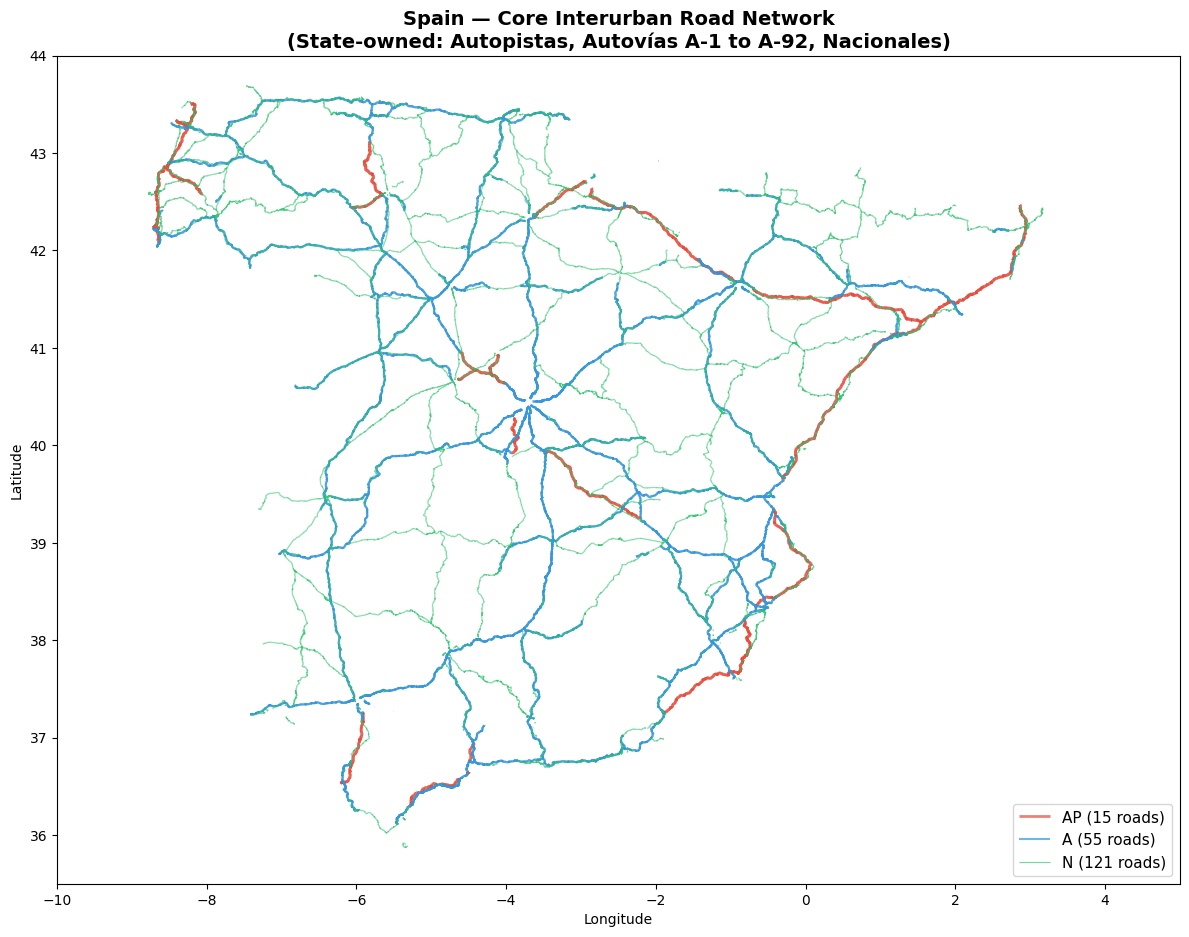

In [7]:
# ── Map: color-coded by road type ──

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

colors = {'AP': '#e74c3c', 'A': '#3498db', 'N': '#2ecc71'}

for rtype, color in colors.items():
    sub = roads_core[roads_core['road_type'] == rtype]
    if len(sub) > 0:
        lw = 2.0 if rtype == 'AP' else (1.5 if rtype == 'A' else 0.8)
        n_roads = sub['road'].nunique()
        sub.plot(ax=ax, color=color, linewidth=lw,
                 label=f"{rtype} ({n_roads} roads)", alpha=0.7)

ax.set_title("Spain — Core Interurban Road Network\n"
             "(State-owned: Autopistas, Autovías A-1 to A-92, Nacionales)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(-10, 5)
ax.set_ylim(35.5, 44)
plt.tight_layout()
plt.show()


## 7. Save processed data

- **Primary output:** `roads_interurban.geojson` — all ~217k segments with full detail (fed into notebook 02 for spatial buffer around chargers).
- **Secondary output:** `roads_interurban_dissolved.geojson` — one feature per road (fed into notebook 04 for placement optimization).
- **Format choice:** GeoJSON is portable, human-readable, and doesn't need a proprietary driver.
- **Size:** ~50 MB full / ~20 MB dissolved — small enough to commit alongside the notebooks.


In [8]:
# ── Save GeoJSON for downstream notebooks ──

OUTPUT = "../data/processed/roads_interurban.geojson"
os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)

# Keep only essential columns to reduce file size
keep_cols = ['road', 'road_type', 'road_type_label', 'length_km', 'geometry']
# Add CNIG columns that may be useful downstream
for c in ['nombre', 'clased', 'titulard']:
    if c in roads_core.columns:
        keep_cols.append(c)

out = roads_core[[c for c in keep_cols if c in roads_core.columns]].copy()

# Idempotent save — skip if the output already exists (re-run safety on read-only mounts)
if os.path.exists(OUTPUT):
    fsize = os.path.getsize(OUTPUT) / 1024 / 1024
    print(f"{OUTPUT} already exists ({fsize:.1f} MB) — skipping overwrite.")
else:
    out.to_file(OUTPUT, driver="GeoJSON")
    fsize = os.path.getsize(OUTPUT) / 1024 / 1024
    print(f"Saved {len(out):,} segments -> {OUTPUT} ({fsize:.1f} MB)")

# Summary for downstream notebooks
print(f"\n{'='*50}")
print(f"SUMMARY FOR DOWNSTREAM USE")
print(f"{'='*50}")
print(f"  File:    {OUTPUT}")
print(f"  Roads:   {out['road'].nunique()} unique designations")
print(f"  Segments:{len(out):,}")
print(f"  Total km:{out['length_km'].sum():,.0f}")
print(f"\n  This feeds into:")
print(f"  - 02_existing_chargers.ipynb (spatial filter: chargers near these roads)")
print(f"  - 03_demand_allocation.ipynb  (corridor definitions)")
print(f"  - 04_station_placement.ipynb  (Set Cover placement on real geometry)")


../data/processed/roads_interurban.geojson already exists (239.3 MB) — skipping overwrite.

SUMMARY FOR DOWNSTREAM USE
  File:    ../data/processed/roads_interurban.geojson
  Roads:   191 unique designations
  Segments:217,392
  Total km:48,155

  This feeds into:
  - 02_existing_chargers.ipynb (spatial filter: chargers near these roads)
  - 03_demand_allocation.ipynb  (corridor definitions)
  - 04_station_placement.ipynb  (Set Cover placement on real geometry)


In [9]:
# ── Save dissolved version (one feature per road, for quick loading in NB 04) ──

OUTPUT_DISSOLVED = "../data/processed/roads_interurban_dissolved.geojson"

if os.path.exists(OUTPUT_DISSOLVED):
    fsize = os.path.getsize(OUTPUT_DISSOLVED) / 1024 / 1024
    print(f"{OUTPUT_DISSOLVED} already exists ({fsize:.1f} MB) — skipping overwrite.")
else:
    roads_dissolved.to_file(OUTPUT_DISSOLVED, driver="GeoJSON")
    fsize = os.path.getsize(OUTPUT_DISSOLVED) / 1024 / 1024
    print(f"Saved dissolved: {len(roads_dissolved)} roads -> {OUTPUT_DISSOLVED} ({fsize:.1f} MB)")
print(f"\nHead of dissolved network (downstream input for placement):")
print(roads_dissolved[['road', 'road_type', 'length_km']].sort_values('length_km', ascending=False).head(10).to_string(index=False))


../data/processed/roads_interurban_dissolved.geojson already exists (178.4 MB) — skipping overwrite.

Head of dissolved network (downstream input for placement):
 road road_type   length_km
  A-7         A 2465.719020
 AP-7        AP 2267.863048
  A-4         A 1859.218296
 A-66         A 1728.652978
  A-2         A 1691.190110
  A-6         A 1377.216499
  A-8         A 1129.085253
N-340         N 1121.257916
  A-5         A 1063.670326
 A-23         A 1031.688370
